# Initial figures

- Sensors: Vectors (ADVs) only, from the QC'd files `data/processed/qc/{S}_QC.nc`.
- Spectral files are saved to 
- Figures are saved to `figs/initial/`.



In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import spectrogram, welch
from granolas import sensor_spectra, multi_spectrogram, compute_H0, Hs_band, ztest

# paths
QC_DIR   = '../data/processed/qc'
META_DIR = '../data/metadata'
FIG_DIR  = '../figs/initial'

# constants
RHO = 1025.0     # seawater density [kg/m^3]
G   = 9.81       # gravity [m/s^2]
FS  = 2.0        # Vector sample rate [Hz]

# barbers point buoy data
buoy = pd.read_csv(f'{META_DIR}/cdip238_waves.csv', index_col='time', parse_dates=True)

# NOAA 1612340 tide data (Honolulu harbor)
tide = pd.read_csv(f'{META_DIR}/noaa_1612340_water_level.csv', index_col=0, parse_dates=True)['Water Level']

# sensors
ALL_SENSORS = ['VA10', 'VB5', 'VC10', 'VC5', 'VD10', 'VD5', 'VE10', 'VE7', 'VE4']
qc = {S: xr.open_dataset(f'{QC_DIR}/{S}_QC.nc') for S in ALL_SENSORS}
for S in ALL_SENSORS:
    t = qc[S].time.values
    print(f'{S:5s} transect {S[1]}  ~{S[2:]:>2s} m   {str(t[0])[:16]} -> {str(t[-1])[:16]}')



FAUSTO = ('2026-07-19', '2026-07-27')
LALA = ('2026-08-11', '2026-08-20')
LOWELL = ('2026-09-07', '2026-09-09')

VA10  transect A  ~10 m   2026-07-19T00:16 -> 2026-09-15T21:18
VB5   transect B  ~ 5 m   2026-07-19T23:13 -> 2026-09-15T20:44
VC10  transect C  ~10 m   2026-07-19T20:34 -> 2026-09-15T19:27
VC5   transect C  ~ 5 m   2026-07-19T01:41 -> 2026-09-15T20:16
VD10  transect D  ~10 m   2026-07-20T00:32 -> 2026-09-15T23:52
VD5   transect D  ~ 5 m   2026-07-18T22:29 -> 2026-09-15T22:10
VE10  transect E  ~10 m   2026-07-20T01:31 -> 2026-09-15T23:23
VE7   transect E  ~ 7 m   2026-07-18T19:56 -> 2026-09-15T22:59
VE4   transect E  ~ 4 m   2026-07-18T21:14 -> 2026-09-15T22:36


## Plot style
- Color = transect: A/B IndianRed, C olive, D cobalt, E near-black.
- Line style = depth: 10 m solid, 7 m dash-dot, 4–5 m dashed.
- Medium-large fonts for slides.

In [2]:
# claude's fancy plot data

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,'axes.titlesize': 15,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 12, 'legend.frameon': False,
    'lines.linewidth': 1.2,
})

# color by transect 
T_COLOR = {'A': 'indianred', 'B': 'indianred', 'C': '#708238', 'D': '#0047AB', 'E': '0.15'}

# line style by depth
DEPTH_LS = {'10': '-', '7': '-.', '5': '--', '4': '--'}

BUOY_COLOR = '0.65'   # light grey 

# usage:  color=T_COLOR[S[1]], ls=DEPTH_LS[S[2:]]

Take spectra and bulk stats. Change inputs accordings **Warning**: takes 5 min to run all the spectra and bulk stats. If you want to run only a subset of sensors, change the `SENSORS` list below.

- To skip this cell, run **Load saved spectra** below instead (seconds instead of ~5 min).
- `SPEC_START`, `SPEC_END` compute the spectra for a date range only (e.g. one event). Saved runs get the dates in the file name.


In [ ]:
# take spectra. make sure to detrend. Use scripts from granolas. 

# ============ INPUTS ============
SENSORS    = ALL_SENSORS    # e.g. ['VC5'] to test one sensor quickly
SPEC_START, SPEC_END = None, None   # e.g. '2026-09-05', '2026-09-12' for an event; None = whole record
NPERSEG    = 1024           # samples per FFT window: 1024 at 2 Hz = 512 s, df = 0.002 Hz
OVERLAP    = 0.5            # window overlap fraction
AVG        = '1h'           # average window spectra over this period before Hs, Tp, Dm
FMIN, FMAX = 0.04, 0.25     # sea-swell band for Hs, Tp, Dm [Hz]
F_CUT      = 0.5            # S_eta set to 0 above this [Hz]
USE_SEG_OK = True           # drop hours that failed QC (seg_ok = False)
# ================================


# Build an xarray dataset for each sensor's spectra
spec = {}
for S in SENSORS:
    ds  = qc[S].sel(time=slice(SPEC_START, SPEC_END))                   # only the requested dates
    df  = ds[['p', 'u', 'v', 'w', 'u_east', 'v_north']].to_dataframe()   # 2 Hz record (~10 M rows)

    # ---- pressure and depth ----
    df['p_Pa']   = df.p * 1e4                          # dbar to Pa (what granolas expects)
    df['p_head'] = df.p * 1e4 / (RHO * G)              # hydrostatic head [m]
    df['h']      = df.p_head.rolling(NPERSEG, center=True, min_periods=1).mean()   # avg to smooth over waves

    # take the spectra
    # 1. surface elevation S_eta from pressure, cosh(kh) transfer
    sp = sensor_spectra(df, nperseg=NPERSEG, overlap_frac=OVERLAP,
                        pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT)

    # 2. pressure-head and velocity spectra, plus the p-velocity co-spectra (for Dm)
    xs = multi_spectrogram(df, columns=['p_head', 'u', 'v', 'w'],
                           pairs=[('p_head', 'u_east'), ('p_head', 'v_north')],
                           nperseg=NPERSEG, overlap_frac=OVERLAP)
    xs = xs.rename({'S_p_head': 'Spp', 'S_u': 'Suu', 'S_v': 'Svv', 'S_w': 'Sww',      # short names
                    'Co_p_head_u_east': 'Co_pE', 'Co_p_head_v_north': 'Co_pN'})
    xs = xs.drop_vars(['Quad_p_head_u_east', 'Quad_p_head_v_north'])                  # not needed here
    sp = sp.merge(xs)                                                                  # one Dataset per sensor
    del df, xs                                                                         # free memory before the next sensor

    # ---- drop windows in hours that failed QC ----
    if USE_SEG_OK:
        win_hour = pd.DatetimeIndex(sp.time.values).floor('h')                 # clock hour of each window center
        ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values      # seg_ok for that hour
        sp = sp.where(xr.DataArray(ok.astype(bool), dims='time'))

    # ---- average window spectra over AVG ----
    sp = sp.resample(time=AVG).mean()

    # ---- Hs, Tp (granolas compute_H0, over FMIN-FMAX) ----
    good = sp.dropna('time', subset=['h_mean'])                    # compute_H0 can't take all-NaN times
    bulk = compute_H0(good, fmin=FMIN, fmax=FMAX)                  # DataFrame: Hs, Tp, H0, h
    bulk = bulk.reindex(sp.time.values)                            # back onto the full time grid
    sp['Hs'] = ('time', bulk.Hs.values)
    sp['Tp'] = ('time', bulk.Tp.values)

    # ---- Dm: direction waves come FROM [deg true] ----
    band   = sp.sel(frequency=slice(FMIN, FMAX))
    toward = np.degrees(np.arctan2(band.Co_pE.sum('frequency'), band.Co_pN.sum('frequency')))
    sp['Dm'] = (toward + 180) % 360
    sp['Dm'] = sp.Dm.where(sp.Hs.notnull())                        # NaN where the hour was dropped

    # ---- labels ----
    sp['Hs'].attrs = {'units': 'm',        'long_name': f'Hs = 4 sqrt(m0), {FMIN}-{FMAX} Hz'}
    sp['Tp'].attrs = {'units': 's',        'long_name': f'peak period, {FMIN}-{FMAX} Hz'}
    sp['Dm'].attrs = {'units': 'deg true', 'long_name': f'mean wave direction, coming FROM, {FMIN}-{FMAX} Hz'}
    sp.attrs.update({'sensor': S, 'transect': S[1], 'depth_m': int(S[2:]),
                     'nperseg': NPERSEG, 'overlap': OVERLAP, 'avg': AVG, 'use_seg_ok': int(USE_SEG_OK),
                     'fmin': FMIN, 'fmax': FMAX, 'spec_start': str(SPEC_START), 'spec_end': str(SPEC_END)})
    spec[S] = sp

    # check: median Hs here / Hs_SS stored in the QC file (same band, hourly) -> should be ~1
    ratio = (sp.Hs.to_series() / ds.Hs_SS.to_series()).median()
    print(f'{S:5s} {int(sp.Hs.notnull().sum()):5d} x {AVG}   median Hs {float(sp.Hs.median()):.2f} m   '
          f'Tp {float(sp.Tp.median()):.1f} s   Hs/Hs_SS {ratio:.3f}')

# file-name tag for saving: '' for the whole record, '_start_end' for a date run (so it doesn't overwrite the full files)
SPEC_TAG = '' if SPEC_START is None else f'_{SPEC_START}_{SPEC_END}'


VA10   1347 x 1h   median Hs 1.20 m   Tp 14.6 s   Hs/Hs_SS 0.989
VB5    1388 x 1h   median Hs 1.17 m   Tp 14.6 s   Hs/Hs_SS 0.994
VC10   1390 x 1h   median Hs 1.12 m   Tp 15.1 s   Hs/Hs_SS 0.988
VC5    1409 x 1h   median Hs 1.02 m   Tp 15.1 s   Hs/Hs_SS 0.989
VD10   1365 x 1h   median Hs 0.92 m   Tp 14.2 s   Hs/Hs_SS 0.984
VD5    1343 x 1h   median Hs 0.96 m   Tp 14.2 s   Hs/Hs_SS 0.990
VE10   1371 x 1h   median Hs 0.91 m   Tp 14.2 s   Hs/Hs_SS 0.985
VE7    1400 x 1h   median Hs 0.87 m   Tp 14.2 s   Hs/Hs_SS 0.988
VE4    1413 x 1h   median Hs 0.88 m   Tp 14.6 s   Hs/Hs_SS 0.991


In [5]:
# save the spectra as netcdf (whole record -> {S}_spec.nc, a date run -> {S}_spec_{start}_{end}.nc)
for S in spec:
    spec[S].to_netcdf(f'{QC_DIR}/{S}_spec{SPEC_TAG}.nc')


#### Load saved spectra
Run this **instead of** the spectra cell above. It reads the `{S}_spec.nc` files written by the save cell. To load a date run, set `LOAD_TAG` to its dates, e.g. `'_2026-09-05_2026-09-12'`.

In [9]:
# load saved spectra instead of rerunning the spectra cell

# ============ INPUTS ============
SENSORS  = ALL_SENSORS
LOAD_TAG = ''      # '' = whole record ({S}_spec.nc), or e.g. '_2026-09-05_2026-09-12' for a date run
# ================================

spec = {}
for S in SENSORS:
    # load_dataset reads the file into memory and closes it, so the save cell can overwrite it later
    spec[S] = xr.load_dataset(f'{QC_DIR}/{S}_spec{LOAD_TAG}.nc')
    t = spec[S].time.values
    print(f'{S:5s} {str(t[0])[:16]} -> {str(t[-1])[:16]}   {len(t)} x {spec[S].attrs["avg"]}')

# settings the figure cells use in their titles (normally set by the spectra cell)
AVG  = spec[S].attrs['avg']
FMIN = spec[S].attrs.get('fmin', 0.04)     # files saved before 2026-10-07 don't store the band; they used 0.04-0.25 Hz
FMAX = spec[S].attrs.get('fmax', 0.25)
SPEC_TAG = LOAD_TAG


VA10  2026-07-19T00:00 -> 2026-09-15T21:00   1414 x 1h
VB5   2026-07-19T23:00 -> 2026-09-15T20:00   1390 x 1h
VC10  2026-07-19T20:00 -> 2026-09-15T19:00   1392 x 1h
VC5   2026-07-19T01:00 -> 2026-09-15T20:00   1412 x 1h
VD10  2026-07-20T00:00 -> 2026-09-15T23:00   1392 x 1h
VD5   2026-07-18T22:00 -> 2026-09-15T22:00   1417 x 1h
VE10  2026-07-20T01:00 -> 2026-09-15T23:00   1391 x 1h
VE7   2026-07-18T20:00 -> 2026-09-15T22:00   1419 x 1h
VE4   2026-07-18T21:00 -> 2026-09-15T22:00   1418 x 1h


#### Bulk stats figs

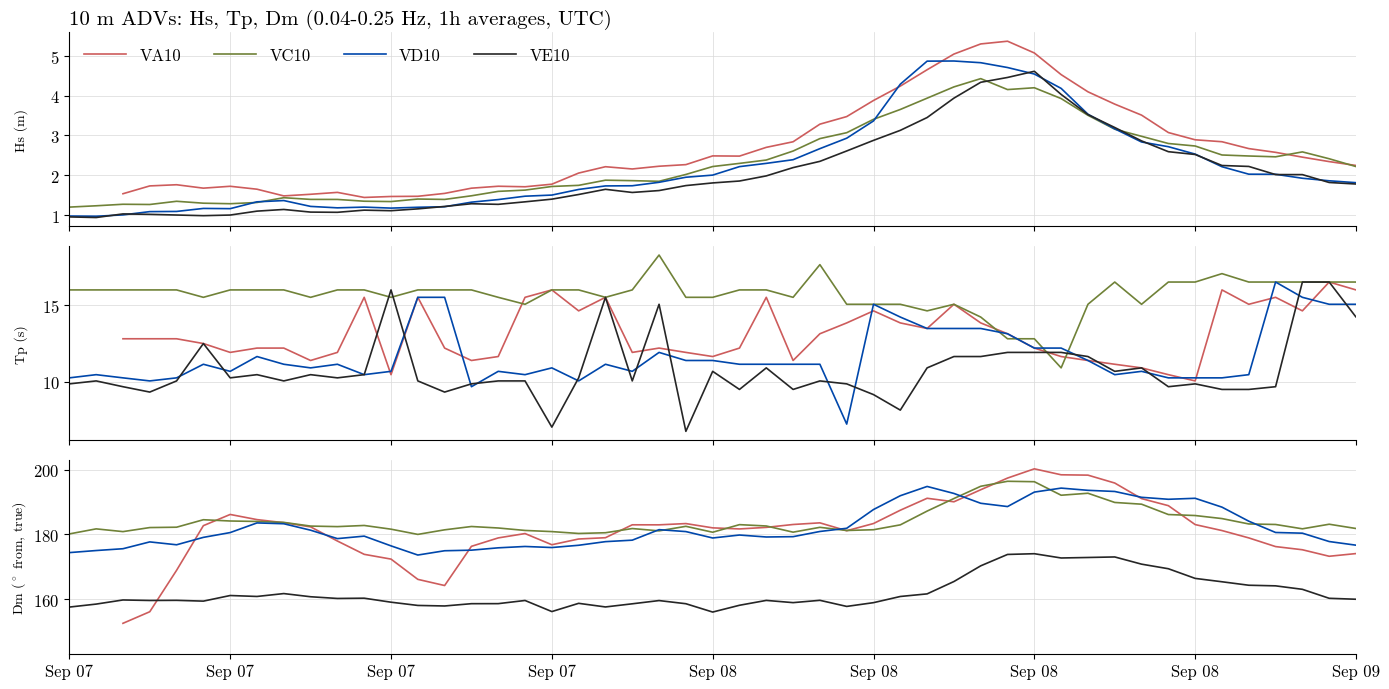

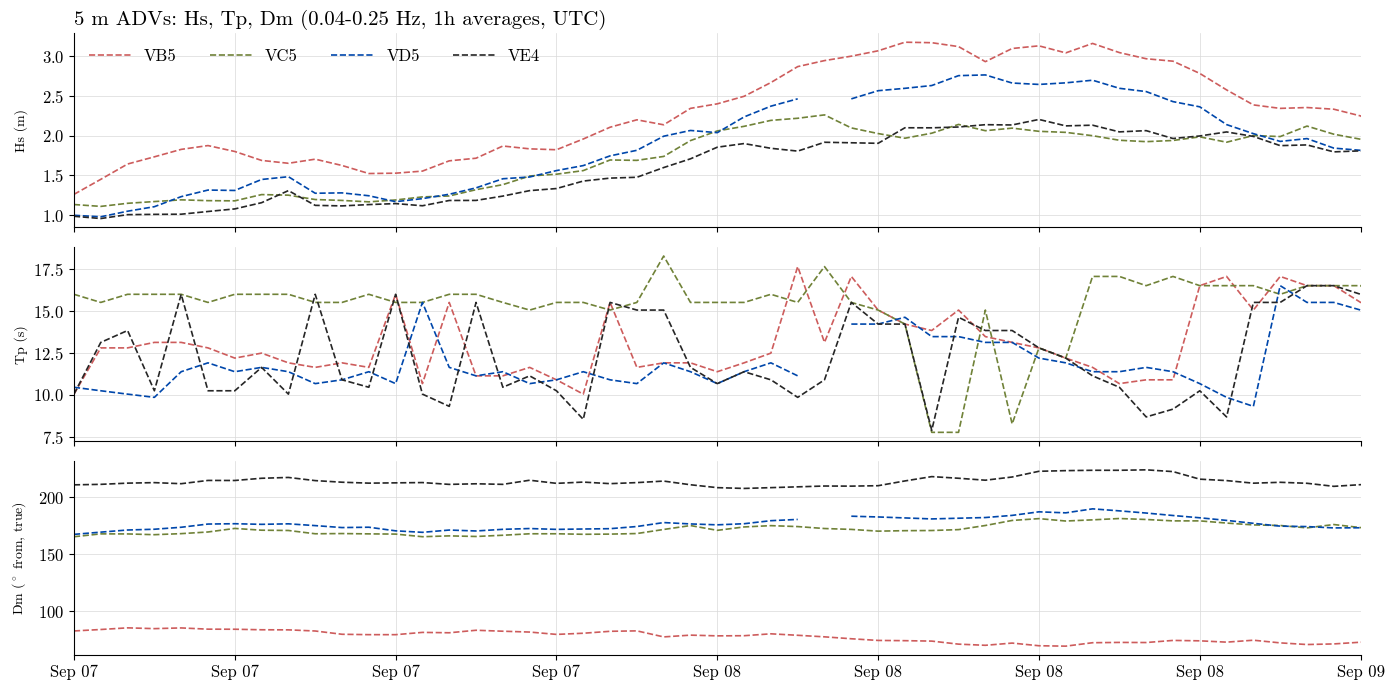

In [10]:
# For both 10m and 5m sensors, make a 3 panel figure with Hs, Tp, and Dm. One figure for 10m, another for 5m. Plot lines for each sensor. For transect E, You may use VE4. Label title clearly

# ============ INPUTS ============
SENSORS_10M = ['VA10', 'VC10', 'VD10', 'VE10']
SENSORS_5M  = ['VB5', 'VC5', 'VD5', 'VE4']
T_START, T_END = LOWELL   # e.g. '2026-09-05', '2026-09-12' to zoom on an event
HS_YLIM   = None            # e.g. (0, 3); None = automatic
TP_YLIM   = None            # e.g. (5, 25)
DM_YLIM   = None            # e.g. (140, 220)
SHOW_BUOY = False
SAVE      = False
# ================================

for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M)]:
    fig, axs = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        axs[0].plot(b.index, b.Hs, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')
        axs[1].plot(b.index, b.Tp, '.', ms=3, color=BUOY_COLOR)
        axs[2].plot(b.index, b.Dp, '.', ms=3, color=BUOY_COLOR)

    for S in sensors:
        if S not in spec:
            print(f'{S} skipped: not in spec (rerun the spectra cell with it in SENSORS)')
            continue
        d = spec[S].sel(time=slice(T_START, T_END))
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs[0].plot(d.time, d.Hs, color=color, ls=ls, label=S)
        axs[1].plot(d.time, d.Tp, color=color, ls=ls)          # steppy: Tp jumps between frequency bins
        axs[2].plot(d.time, d.Dm, color=color, ls=ls)
    axs[0].set_ylabel('Hs (m)')
    axs[1].set_ylabel('Tp (s)')
    axs[2].set_ylabel(r'Dm ($^\circ$ from, true)')
    axs[0].set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs[1].set_ylim(TP_YLIM)
    axs[2].set_ylim(DM_YLIM)
    axs[0].legend(ncol=5, loc='upper left', handlelength=2.5)
    axs[0].set_title(f'{group} ADVs: Hs, Tp, Dm ({FMIN}-{FMAX} Hz, {AVG} averages, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/bulk_{group.replace(" ", "")}_{T_START}_{T_END}.png', dpi=200)
    plt.show()

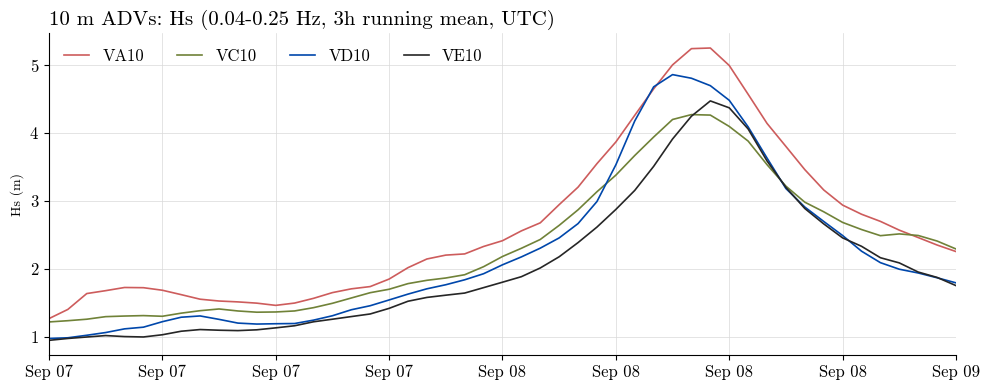

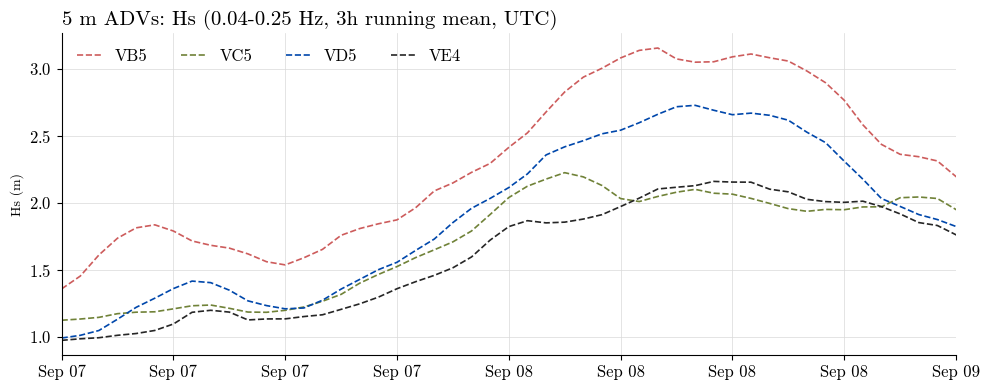

In [11]:
# Hs plot (uses SENSORS_10M, SENSORS_5M, T_START, T_END, HS_YLIM, SHOW_BUOY and SAVE from the cell above)

# ============ INPUTS ============
SMOOTH = '3h'     # centered running mean, e.g. '3h', '6h'; None = no smoothing
# ================================

for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M)]:
    fig, axs = plt.subplots(1, 1, figsize=(10, 4))

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        hs_buoy = b.Hs
        if SMOOTH:
            hs_buoy = hs_buoy.rolling(SMOOTH, center=True).mean()     # running mean over SMOOTH
        axs.plot(hs_buoy.index, hs_buoy, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')


    for S in sensors:
        hs = spec[S].Hs.sel(time=slice(T_START, T_END)).to_series()   # hourly Hs as a pandas Series
        if SMOOTH:
            hs = hs.rolling(SMOOTH, center=True).mean()                # running mean over SMOOTH (skips gaps)
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs.plot(hs.index, hs, color=color, ls=ls, label=S)

    axs.set_ylabel('Hs (m)')
    axs.set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs.legend(ncol=5, loc='upper left', handlelength=1.5)
    smooth_txt = f', {SMOOTH} running mean' if SMOOTH else ''
    axs.set_title(f'{group} ADVs: Hs ({FMIN}-{FMAX} Hz{smooth_txt}, UTC)', loc='left')

    axs.set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axs.grid(True, lw=0.5, color='0.85')
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Hs_{group.replace(" ", "")}_{T_START}_{T_END}.png', dpi=200)   # Hs_ so it doesn't overwrite the 3-panel figure
    plt.show()


#### Bulk stats by transect
Same panels as above, one figure per transect. Color and line style both show depth: 10 m cobalt solid, 7 m olive dash-dot, 4–5 m IndianRed dashed. Transects A and B have one sensor each.

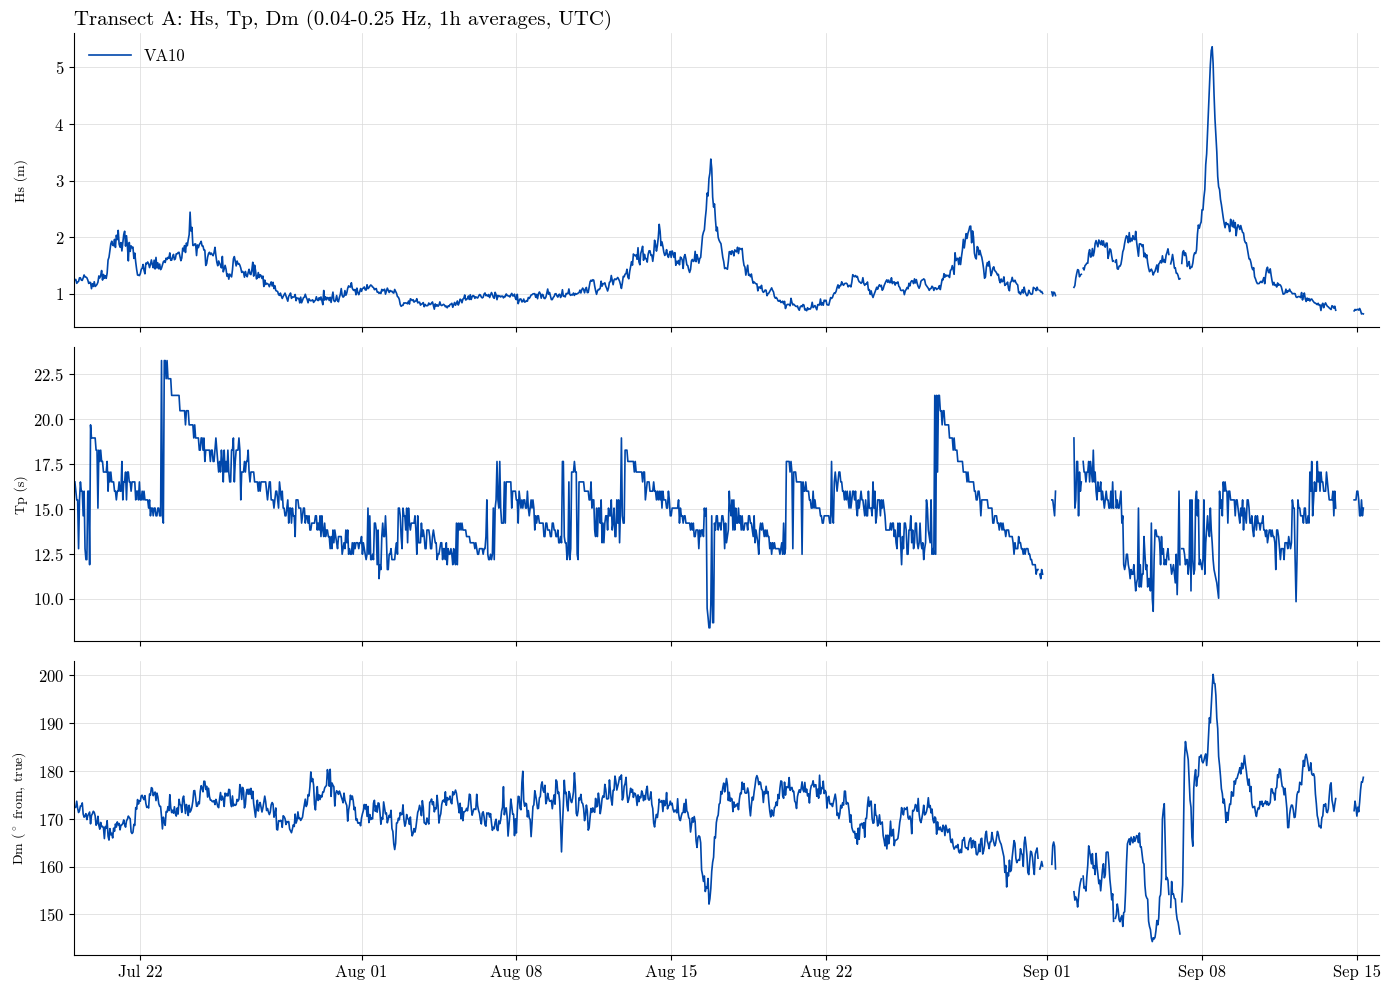

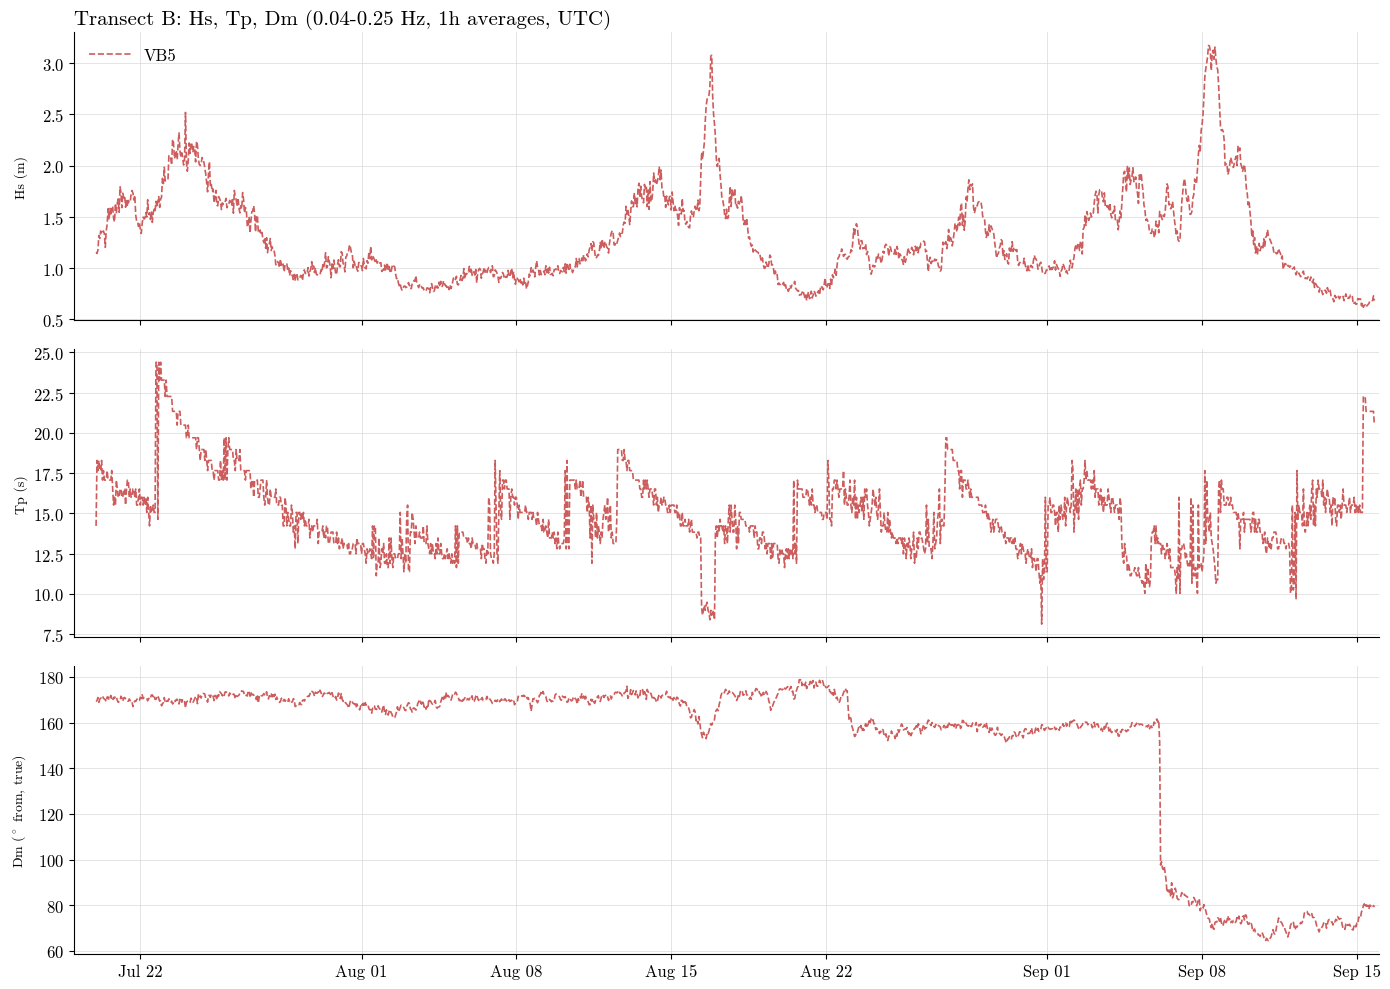

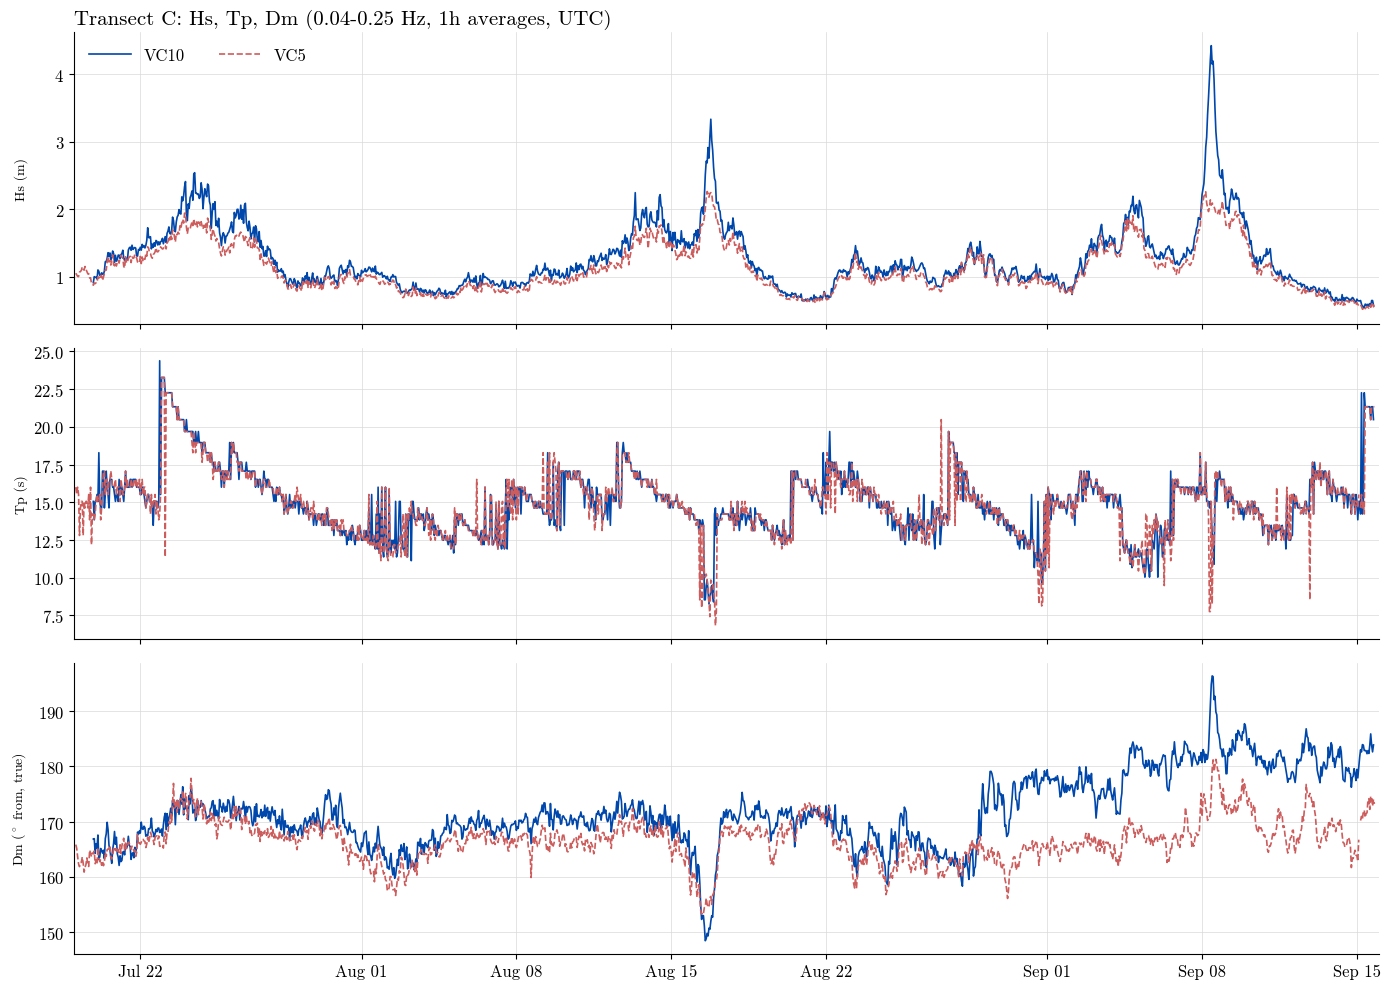

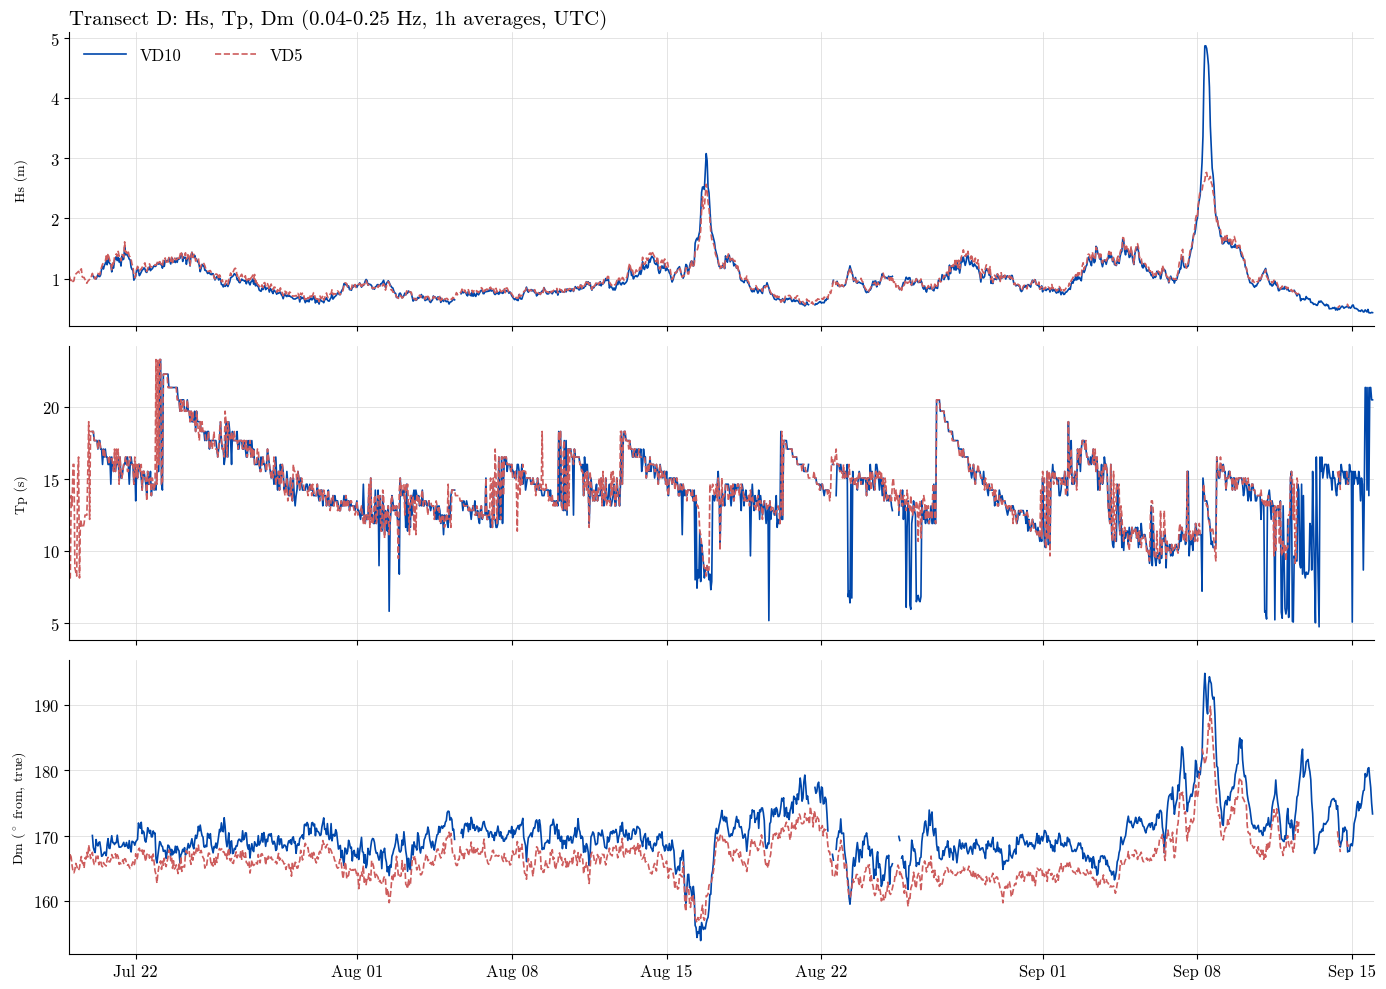

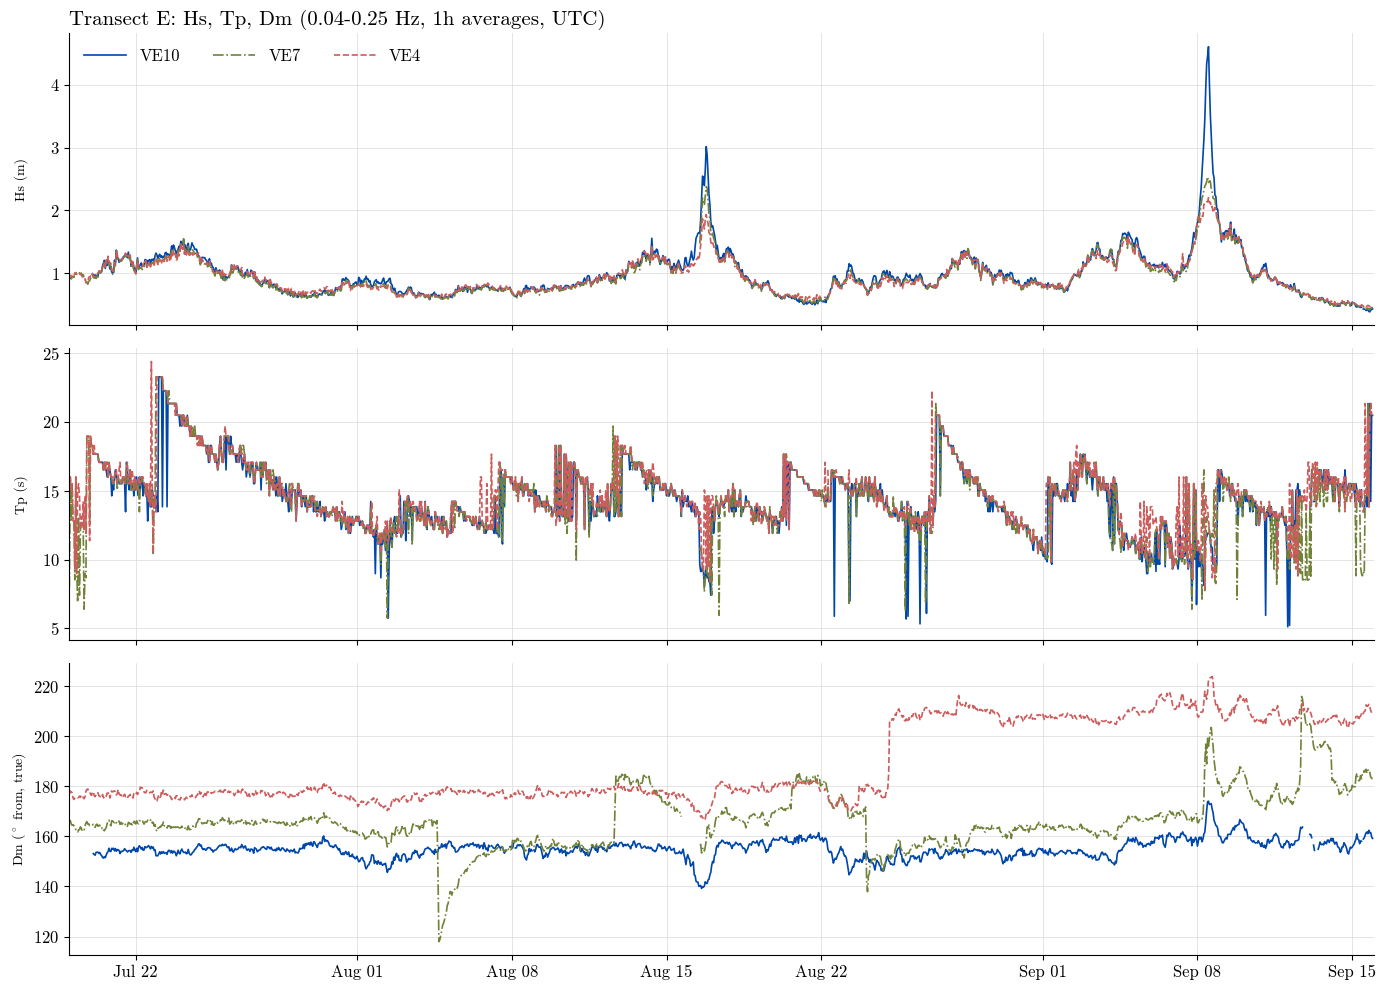

In [108]:
# Hs, Tp, Dm by transect: one 3-panel figure per transect, one line per sensor on that transect

# ============ INPUTS ============
TRANSECTS = ['A', 'B', 'C', 'D', 'E']    # e.g. ['C', 'E']
T_START, T_END = '2026-07-19', '2026-09-16'
HS_YLIM   = None            # e.g. (0, 3); None = automatic
TP_YLIM   = None            # e.g. (5, 25)
DM_YLIM   = None            # e.g. (140, 220)
SHOW_BUOY = False
SAVE      = False
# ================================

# within one transect every sensor has the same transect color, so color by depth here instead
DEPTH_COLOR = {'10': '#0047AB', '7': '#708238', '5': 'indianred', '4': 'indianred'}

for T in TRANSECTS:
    sensors = [S for S in spec if S[1] == T]           # sensors on this transect, deep -> shallow
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        axs[0].plot(b.index, b.Hs, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')
        axs[1].plot(b.index, b.Tp, '.', ms=3, color=BUOY_COLOR)
        axs[2].plot(b.index, b.Dp, '.', ms=3, color=BUOY_COLOR)

    for S in sensors:
        d = spec[S].sel(time=slice(T_START, T_END))
        color, ls = DEPTH_COLOR[S[2:]], DEPTH_LS[S[2:]]
        axs[0].plot(d.time, d.Hs, color=color, ls=ls, label=S)
        axs[1].plot(d.time, d.Tp, color=color, ls=ls)
        axs[2].plot(d.time, d.Dm, color=color, ls=ls)

    axs[0].set_ylabel('Hs (m)')
    axs[1].set_ylabel('Tp (s)')
    axs[2].set_ylabel(r'Dm ($^\circ$ from, true)')
    axs[0].set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs[1].set_ylim(TP_YLIM)
    axs[2].set_ylim(DM_YLIM)
    axs[0].legend(ncol=4, loc='upper left', handlelength=2.5)
    axs[0].set_title(f'Transect {T}: Hs, Tp, Dm ({FMIN}-{FMAX} Hz, {AVG} averages, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/bulk_transect{T}_{T_START}_{T_END}.png', dpi=200)
    plt.show()


#### Hs by frequency band: Hs_tot, Hs_ss, Hs_ig


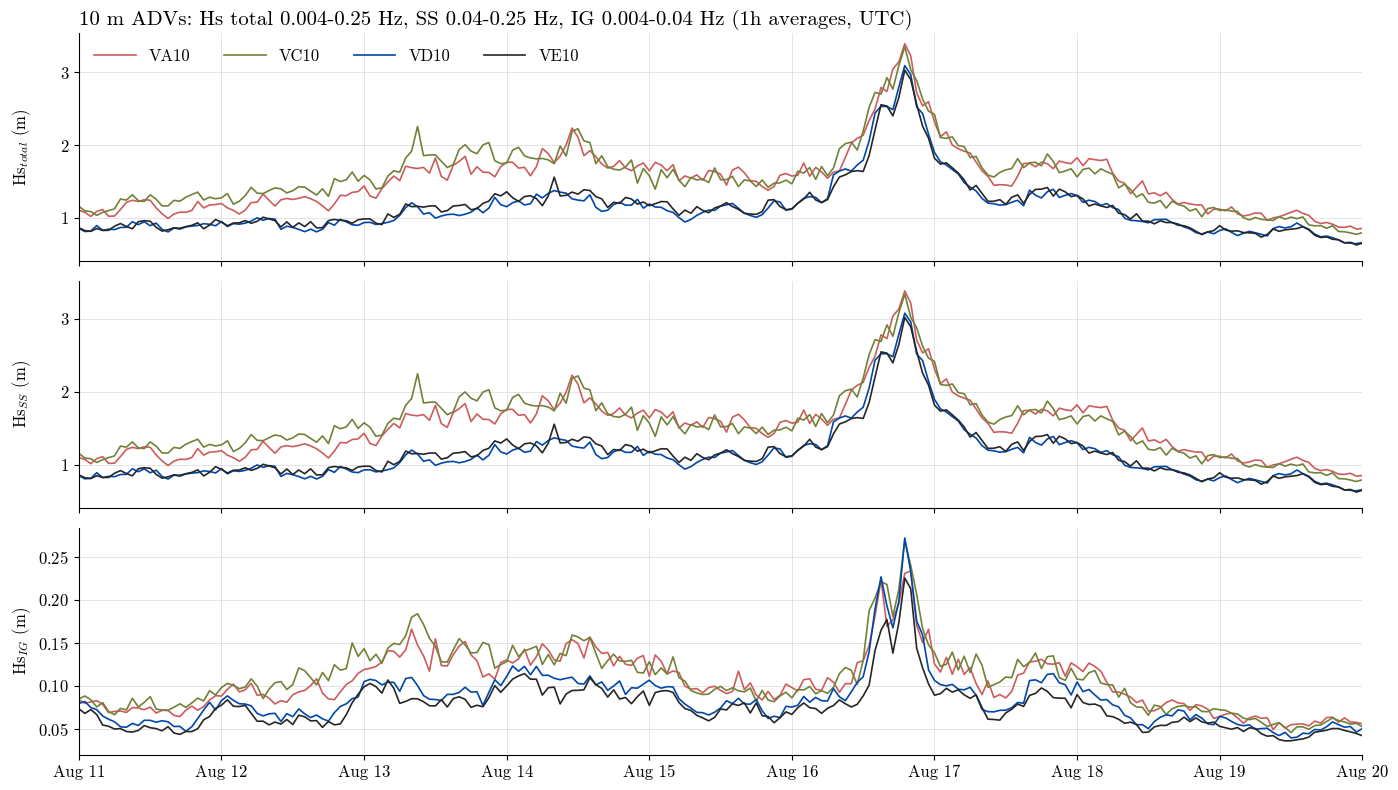

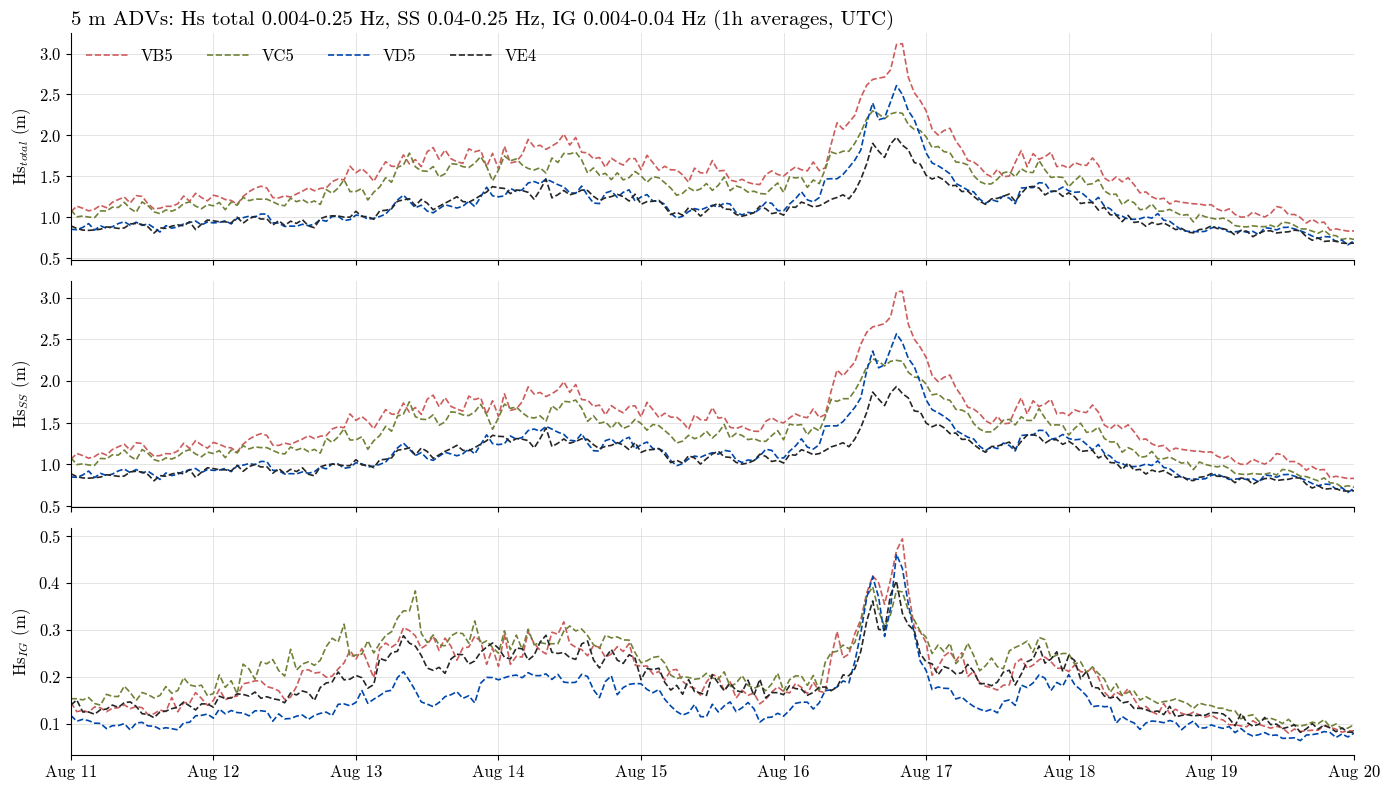

In [6]:
# Hs in three bands: total, sea-swell (SS) and infragravity (IG). One 3-panel figure for 10 m, one for 5 m

# ============ INPUTS ============
SENSORS_10M = ['VA10', 'VC10', 'VD10', 'VE10']
SENSORS_5M  = ['VB5', 'VC5', 'VD5', 'VE4']
T_START, T_END = LALA
IG_BAND    = (0.004, 0.04)        # infragravity [Hz]
SS_BAND    = (0.04, 0.25)         # sea-swell [Hz]
TOTAL_BAND = (0.004, 0.25)        # total = IG + SS [Hz]
TOTAL_YLIM, SS_YLIM, IG_YLIM = None, None, None   # e.g. (0, 3); None = automatic
SAVE = True
# ================================

# Hs = 4 sqrt(m0), m0 = integral of S_eta over the band (granolas Hs_band)
for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M)]:
    fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for S in sensors:
        if S not in spec:
            print(f'{S} skipped: not in spec (run the spectra or load cell with it in SENSORS)')
            continue
        d = spec[S].sel(time=slice(T_START, T_END))
        hs_total = Hs_band(d, *TOTAL_BAND)
        hs_ss    = Hs_band(d, *SS_BAND)
        hs_ig    = Hs_band(d, *IG_BAND)
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs[0].plot(d.time, hs_total, color=color, ls=ls, label=S)
        axs[1].plot(d.time, hs_ss,    color=color, ls=ls)
        axs[2].plot(d.time, hs_ig,    color=color, ls=ls)

    axs[0].set_ylabel(r'Hs$_{total}$ (m)', fontsize=12)
    axs[1].set_ylabel(r'Hs$_{SS}$ (m)', fontsize=12)
    axs[2].set_ylabel(r'Hs$_{IG}$ (m)', fontsize=12 )
    axs[0].set_ylim(TOTAL_YLIM)                     # None leaves the limits automatic
    axs[1].set_ylim(SS_YLIM)
    axs[2].set_ylim(IG_YLIM)
    axs[0].legend(ncol=4, loc='upper left', handlelength=2.5)
    axs[0].set_title(f'{group} ADVs: Hs total {TOTAL_BAND[0]}-{TOTAL_BAND[1]} Hz, '
                     f'SS {SS_BAND[0]}-{SS_BAND[1]} Hz, IG {IG_BAND[0]}-{IG_BAND[1]} Hz ({AVG} averages, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Hs_bands_{group.replace(" ", "")}_{T_START}_{T_END}.png', dpi=200)
    plt.show()


#### Hs_SS vs Hs_IG
One panel per sensor, each point is one hour, colored by water level $h$ (hourly mean depth from the pressure, `h_mean`).
- `H_TIDE = True`: $h$ minus each sensor's own record mean, i.e. the tide and setup. This puts all sensors on one color scale.
- `H_TIDE = False`: total depth $h$. The 5 m and 10 m sensors then sit at opposite ends of the scale.

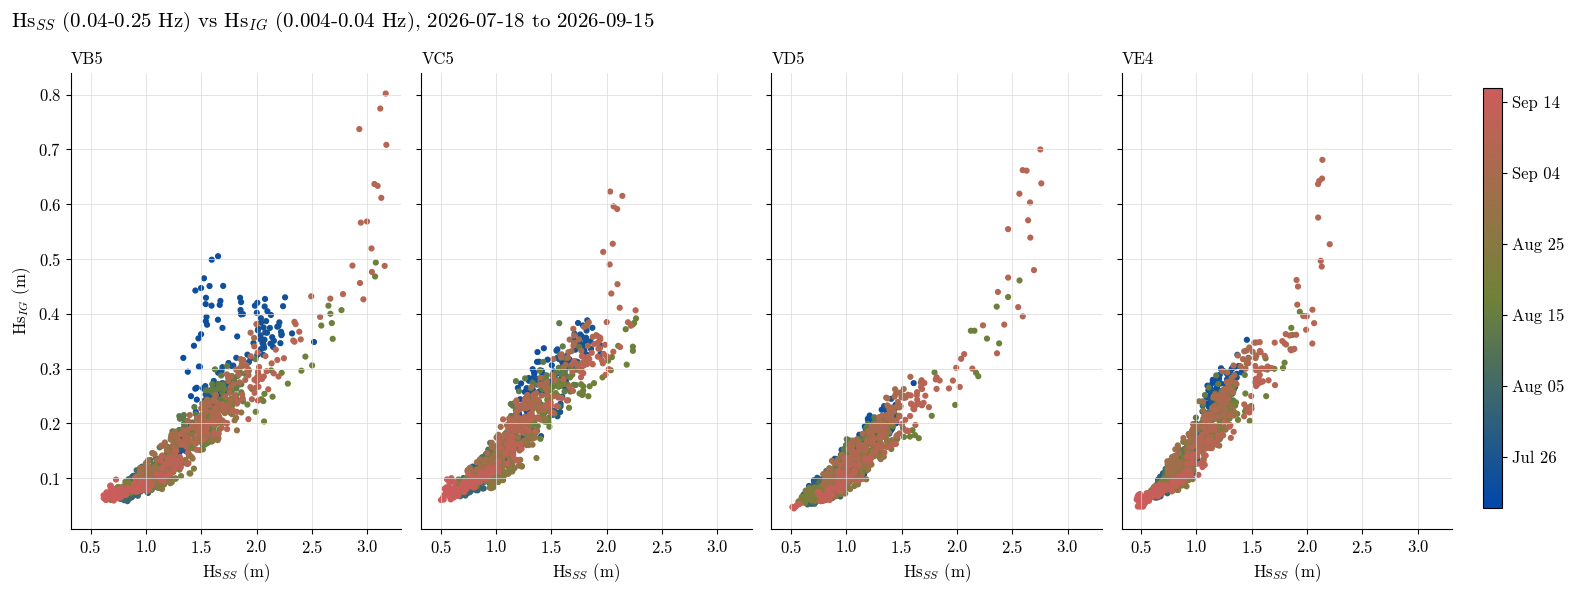

In [8]:
# Hs_SS vs Hs_IG scatter, one panel per sensor, points colored by water level h

# ============ INPUTS ============
SENSORS = [ 'VB5',  'VC5',  'VD5',  'VE4']       # bottom row: 5 m
T_START, T_END = None, None    # e.g. '2026-09-05', '2026-09-12' for one event
IG_BAND = (0.004, 0.04)                         # infragravity [Hz]
SS_BAND = (0.04, 0.25)                          # sea-swell [Hz]
NCOLS   = 4                                     # panels per row
H_TIDE  = True                                  # True: h minus the sensor's mean (tide); False: total depth h
SAVE    = False
# ================================

from matplotlib.colors import LinearSegmentedColormap
h_cmap = LinearSegmentedColormap.from_list('h', ['indianred', '#708238', '#0047AB'])   # low water -> high water
# date window for the title and file name. None -> the data's own first / last time
start = pd.Timestamp(T_START) if T_START is not None else min(pd.Timestamp(spec[S].time.values[0])  for S in SENSORS)
end   = pd.Timestamp(T_END)   if T_END   is not None else max(pd.Timestamp(spec[S].time.values[-1]) for S in SENSORS)

# water level for each sensor (hourly), and one color scale for all panels
h = {}
for S in SENSORS:
    h[S] = spec[S].h_mean.sel(time=slice(T_START, T_END))
    if H_TIDE:
        h[S] = h[S] - spec[S].h_mean.mean()          # minus the sensor's whole-record mean depth
all_h = np.concatenate([h[S].values for S in SENSORS])
h_min, h_max = np.nanpercentile(all_h, 1), np.nanpercentile(all_h, 99)

nrows = int(np.ceil(len(SENSORS) / NCOLS))
fig, axs = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 6 * nrows), sharex=True, sharey=True, squeeze=False)

for ax, S in zip(axs.flat, SENSORS):
    d     = spec[S].sel(time=slice(T_START, T_END))
    hs_ss = Hs_band(d, *SS_BAND)
    hs_ig = Hs_band(d, *IG_BAND)
    sc = ax.scatter(hs_ss, hs_ig, c=h[S], cmap=h_cmap, vmin=h_min, vmax=h_max, s=6, lw=2)
    ax.set_title(S, loc='left', fontweight='bold', fontsize=12)
    ax.grid(True, lw=0.5, color='0.85')

for ax in axs.flat[len(SENSORS):]:          # hide unused panels
    ax.set_visible(False)
for ax in axs[-1, :]:
    ax.set_xlabel(r'Hs$_{SS}$ (m)', fontsize=12)
for ax in axs[:, 0]:
    ax.set_ylabel(r'Hs$_{IG}$ (m)', fontsize=12)

fig.suptitle(f'Hs$_{{SS}}$ ({SS_BAND[0]}-{SS_BAND[1]} Hz) vs Hs$_{{IG}}$ ({IG_BAND[0]}-{IG_BAND[1]} Hz), '
             f'{start:%Y-%m-%d} to {end:%Y-%m-%d}', x=0.01, ha='left', fontsize=15)
fig.tight_layout(rect=(0, 0, 0.92, 1))
cax = fig.add_axes([0.93, 0.15, 0.012, 0.7])                     # colorbar on the right
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('water level, h - mean h (m)' if H_TIDE else 'water depth h (m)')
if SAVE:
    fig.savefig(f'{FIG_DIR}/Hs_SS_vs_IG_{start:%Y-%m-%d}_{end:%Y-%m-%d}.png', dpi=200)
plt.show()


#### A.2 Pressure spectrogram per sensor
Hourly spectra from `spec` (log f × time), one panel per sensor, all on one color scale. *Look for dispersive swell arrivals: frequency rising over days gives the source distance and time. Do arrivals differ across the array (refraction or sheltering)?*
- `Spp` is pressure head and is **not** depth corrected, so the 10 m sensors lose energy faster at high f. `Seta` is depth corrected, but it is capped and set to 0 above `F_CUT`.
- Blank columns are hours dropped by `seg_ok`.

In [ ]:
# A.2 pressure spectrogram per sensor (log f x time). Look for dispersive swell arrivals: frequency rising over days

# ============ INPUTS ============
SENSORS  = ALL_SENSORS                  # one panel per sensor, top to bottom
T_START, T_END = None, None             # None = whole record, or e.g. '2026-09-05', '2026-09-12'
VARIABLE = 'Spp'                        # 'Spp' = pressure head (not depth corrected), 'Seta' = surface elevation
F_RANGE  = (0.004, 0.3)                 # frequencies shown [Hz]
LOG_F    = True                         # log frequency axis
CLIM_PCT = (30, 99.9)                   # color limits = these percentiles of all plotted values (quiet floor stays pale)
SAVE     = True
# ================================

from matplotlib.colors import LinearSegmentedColormap, LogNorm
spec_cmap = LinearSegmentedColormap.from_list('spec', ['white', '#9DB4DA', '#0047AB', 'indianred', '#5A1A1A'])

# date window. None -> the data's own first / last time
start = pd.Timestamp(T_START) if T_START is not None else min(pd.Timestamp(spec[S].time.values[0])  for S in SENSORS)
end   = pd.Timestamp(T_END)   if T_END   is not None else max(pd.Timestamp(spec[S].time.values[-1]) for S in SENSORS)

# one color scale for every panel, so the sensors can be compared
all_values = np.concatenate([spec[S][VARIABLE].sel(time=slice(start, end), frequency=slice(*F_RANGE)).values.ravel()
                             for S in SENSORS])
norm = LogNorm(vmin=np.nanpercentile(all_values, CLIM_PCT[0]), vmax=np.nanpercentile(all_values, CLIM_PCT[1]))

fig, axs = plt.subplots(len(SENSORS), 1, figsize=(14, 1.5 * len(SENSORS) + 1), sharex=True, sharey=True, squeeze=False)
axs = axs[:, 0]
for ax, S in zip(axs, SENSORS):
    d  = spec[S][VARIABLE].sel(time=slice(start, end), frequency=slice(*F_RANGE))   # dropped hours are NaN -> blank
    d  = d.transpose('frequency', 'time')                                           # rows = frequency, columns = time
    pc = ax.pcolormesh(d.time, d.frequency, d, cmap=spec_cmap, norm=norm, shading='nearest', rasterized=True)
    if LOG_F:
        ax.set_yscale('log')
    ax.set_ylabel(S, color=T_COLOR[S[1]], fontweight='bold', rotation=0, ha='right', va='center')

axs[-1].set_xlim(start, end)
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axs[0].set_title(f'Hourly {VARIABLE} spectra, f = {F_RANGE[0]}-{F_RANGE[1]} Hz (y axis, Hz), UTC', loc='left')
fig.tight_layout(rect=(0, 0, 0.92, 1))
cax = fig.add_axes([0.93, 0.25, 0.012, 0.5])                      # colorbar on the right
fig.colorbar(pc, cax=cax, label=f'{VARIABLE} (m$^2$/Hz)')
if SAVE:
    fig.savefig(f'{FIG_DIR}/A2_spectrogram_{VARIABLE}_{start:%Y-%m-%d}_{end:%Y-%m-%d}.png', dpi=200)
plt.show()


## Transect datasets
One Dataset per transect, with the sensors stacked on a `sensor` dimension. Example: `transects['E'].Seta.sel(sensor='VE10')`.

In [6]:
# build transect datasets. Each transect is labelled A-E. The sensors title tells you which transect by the second letter in the sensor name. 
# combine spectral datasets from each sensor for each transect

transects = {}
for T in 'ABCDE':
    members = [S for S in spec if S[1] == T]           # sensors on this transect (deep -> shallow)
    if not members:
        continue
    transects[T] = xr.concat([spec[S] for S in members], dim=pd.Index(members, name='sensor'),
                             join='outer', combine_attrs='drop')
    print(T, members)

transects['E']

A ['VA10']
B ['VB5']
C ['VC10', 'VC5']
D ['VD10', 'VD5']
E ['VE10', 'VE7', 'VE4']


<xarray.Dataset> Size: 288MB
Dimensions:    (sensor: 3, time: 1420, frequency: 1537)
Coordinates:
  * frequency  (frequency) float64 12kB 0.0 0.001953 0.001953 ... 1.0 1.0 1.0
  * time       (time) datetime64[ns] 11kB 2026-07-18T20:00:00 ... 2026-09-15T...
  * sensor     (sensor) object 24B 'VE10' 'VE7' 'VE4'
Data variables:
    Seta       (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    h_mean     (sensor, time) float64 34kB nan nan nan nan ... 4.215 nan nan
    Spp        (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Suu        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Svv        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Sww        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Co_pE      (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Co_pN      (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Hs         (sensor, time) float64 34kB nan nan nan nan ... 0.4775 nan nan
    Tp         (sensor, time) float64 34kB nan nan nan nan ... 20.48 nan nan
    Dm         (sensor, time) float64 34kB nan nan nan nan ... 209.4 nan nan

## Whole-record spectrum, all ADVs
- One spectrum per sensor over the whole record, or over `T_START`–`T_END`.
- It uses Welch (linear detrend, Hann window) instead of one raw FFT. A single FFT of ~10 M points has only 2 degrees of freedom per bin, so it is pure noise. Welch averages the FFTs of `NPERSEG_FULL`-long windows.
  - Bigger `NPERSEG_FULL` gives finer frequency resolution (lower f) but a noisier spectrum.
- Pressure is shown as pressure head (m²/Hz), **not** depth corrected, so the deep sensors drop off faster at high f.

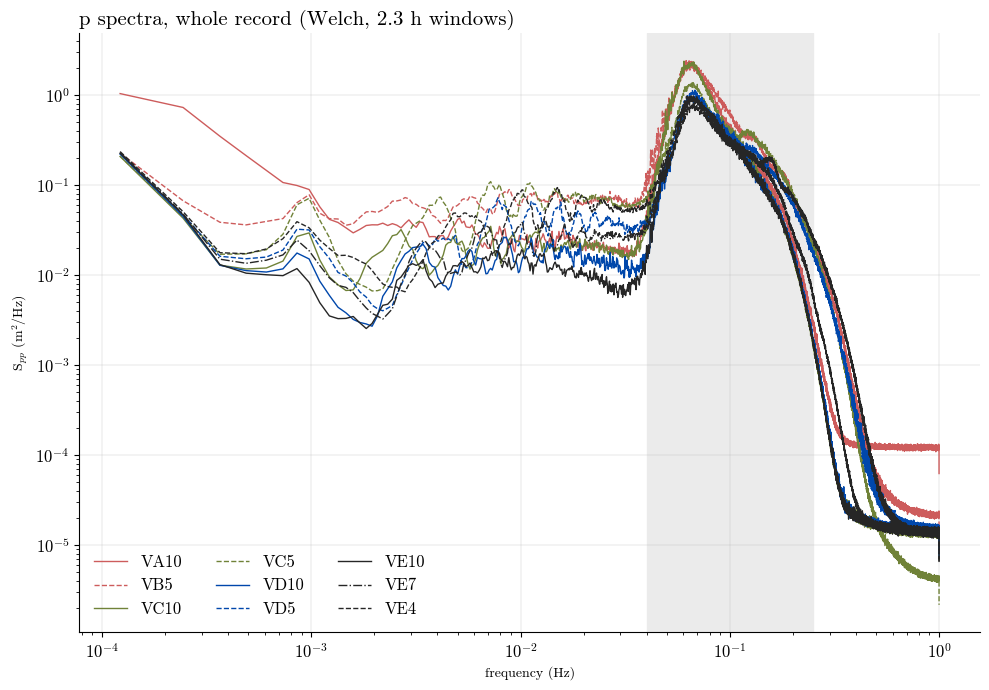

In [42]:
# spectral figure of the whole time series. Like just fft the whole time series and plot the spectra with all of the ADVs on the same plot. Use loglog axis. Use the same color scheme as the other plots. Make sure to label the axes and add a legend.

# ============ INPUTS ============
SENSORS      = ALL_SENSORS
VARIABLE     = 'p'           # 'p' (pressure head), 'u' (cross-shore), 'v' (alongshore), 'w', 'u_east', 'v_north'
T_START, T_END = None, None  # None = whole record, or e.g. '2026-09-05', '2026-09-12'
NPERSEG_FULL = 2**14         # 16384 samples = 2.3 h windows, df = 1.2e-4 Hz
SHADE_BAND   = (0.04, 0.25)  # light grey band [Hz], or None
SAVE         = True
# ================================

YLABEL = {'p': 'S$_{pp}$ (m$^2$/Hz)',  'u': 'S$_{uu}$ (m$^2$ s$^{-2}$/Hz)', 'v': 'S$_{vv}$ (m$^2$ s$^{-2}$/Hz)',
          'w': 'S$_{ww}$ (m$^2$ s$^{-2}$/Hz)', 'u_east': 'S (east) (m$^2$ s$^{-2}$/Hz)', 'v_north': 'S (north) (m$^2$ s$^{-2}$/Hz)'}

fig, ax = plt.subplots(figsize=(12, 7))
for S in SENSORS:
    x = qc[S][VARIABLE].sel(time=slice(T_START, T_END)).values
    if VARIABLE == 'p':
        x = x * 1e4 / (RHO * G)                       # dbar -> m of water
    f, Sxx = welch(x, fs=FS, window='hann', nperseg=NPERSEG_FULL, detrend='linear')
    ax.loglog(f[1:], Sxx[1:], color=T_COLOR[S[1]], ls=DEPTH_LS[S[2:]], lw=1, label=S)   # f[1:] skips f = 0

if SHADE_BAND:
    ax.axvspan(*SHADE_BAND, color='0.92', zorder=0)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel(YLABEL[VARIABLE])
window = 'whole record' if T_START is None else f'{T_START} to {T_END}'
ax.set_title(f'{VARIABLE} spectra, {window} (Welch, {NPERSEG_FULL / FS / 3600:.1f} h windows)', loc='left')
ax.legend(ncol=3, loc='lower left')
ax.grid(True, lw=0.2)
fig.tight_layout()
if SAVE:
    tag = 'all' if T_START is None else f'{T_START}_{T_END}'
    fig.savefig(f'{FIG_DIR}/spectrum_{VARIABLE}_{tag}.png', dpi=200)
plt.show()